In [1]:
import sys
sys.path.insert(0, '.')

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from utils.plotting import (
    TEXTWIDTH_IN, LABEL_SIZE, TICK_SIZE, EMPHASIS_SIZE,
    LW_FINE, LW_GUIDE, NEUTRAL_COLOR, PRIMARY_COLOR,
    SCATTER_S_FINE,
)

def _ha_fmt(deg, pos=None):
    """Format decimal degrees as LaTeX $±HH^h MM^m$ (hour angle, no seconds)."""
    sign = '-' if deg < 0 else '+'
    h_abs = abs(deg) / 15.0
    hh = int(h_abs)
    mm = round((h_abs - hh) * 60)
    if mm == 60:
        hh += 1; mm = 0
    return rf'${sign}{hh}^h\,{mm:02d}^m$'

HA_FMT = mticker.FuncFormatter(_ha_fmt)

In [2]:
# ── Load ──────────────────────────────────────────────────────────────────
DATA_DIR = Path('../../data/lab03/m1_calibration')
PLOT_BAND_GHZ = (9.9, 10.0)

paths = sorted(DATA_DIR.glob('*.npz'))
files = [np.load(p) for p in paths]

f0       = files[0]
F_S_HZ   = float(f0['f_s_hz'])   if 'f_s_hz'   in f0 else 500e6
F_RF0_HZ = float(f0['f_rf0_hz']) if 'f_rf0_hz' in f0 else 9790e6
N_CH     = int(f0['corr'].shape[0])
N_FFT    = int(f0['n_fft'])       if 'n_fft'    in f0 else 2048
DF_HZ    = F_S_HZ / N_FFT
F_SKY_GHZ = (F_RF0_HZ + np.arange(N_CH) * DF_HZ) / 1e9

print(f'Loaded {len(files)} captures  |  '
      f'{F_SKY_GHZ[0]:.4f} -- {F_SKY_GHZ[-1]:.4f} GHz  |  '
      f'{DF_HZ/1e3:.1f} kHz/ch')

# ── Mask ──────────────────────────────────────────────────────────────────
BAD_CHANNELS = [0, 256, 512, 768]   # DC/LO leak + FPGA harmonics (N_FFT/8)

all_amp                  = np.array([np.abs(f['corr']) for f in files]).astype(float)
all_amp[:, BAD_CHANNELS] = np.nan

print(f'Masked : {BAD_CHANNELS}  '
      f'({[f"{F_SKY_GHZ[k]:.4f} GHz" for k in BAD_CHANNELS]})')

# ── Normalise ─────────────────────────────────────────────────────────────
AMP_PEAK = np.nanmax(all_amp)
print(f'Peak   : {AMP_PEAK:.4f}  (max of unmasked channels across all captures)')

# # ── Plot: per-capture spectra grid ────────────────────────────────────────
# n     = len(files)
# NCOLS = 4
# nrows = int(np.ceil(n / NCOLS))
#
# fig, axes = plt.subplots(nrows, NCOLS, figsize=(TEXTWIDTH_IN, 2.2 * nrows))
# axes_flat = np.array(axes).flatten()
#
# for i, f in enumerate(files):
#     ax  = axes_flat[i]
#     amp = np.abs(f['corr']).astype(float) / AMP_PEAK
#     amp[BAD_CHANNELS] = np.nan
#     ax.plot(F_SKY_GHZ, amp, lw=LW_FINE, color=PRIMARY_COLOR)
#     ax.set_title(
#         rf'\textrm{{cap\,{i:03d}}}' + '\n' +
#         rf'$\mathrm{{Alt}}={float(f["alt_deg"]):.1f}^{{\circ}}$',
#     )
#     if i % NCOLS == 0:
#         ax.set_ylabel(r'$|V_{12}| / |V_{12}|_{\rm peak}$')
#     if i >= (nrows - 1) * NCOLS:
#         ax.set_xlabel(r'$f_{\rm sky}$ [GHz]')
#         ax.tick_params(axis='x', rotation=30)
#     ax.set_xlim(*PLOT_BAND_GHZ)
#     ax.set_ylim(0, 1.05)
#
# for ax in axes_flat[n:]:
#     ax.set_visible(False)
#
# fig.suptitle(
#     rf'M1 / Crab Nebula --- cross-correlation spectra '
#     rf'({n}\,captures, $\Delta f={DF_HZ/1e3:.1f}$\,kHz)',
# )
# fig.tight_layout()
# plt.show()

Loaded 506 captures  |  9.7900 -- 10.0398 GHz  |  244.1 kHz/ch
Masked : [0, 256, 512, 768]  (['9.7900 GHz', '9.8525 GHz', '9.9150 GHz', '9.9775 GHz'])
Peak   : 0.6866  (max of unmasked channels across all captures)


In [3]:
# ---------------------------------------------------------------------------
# Compute hour angle for each capture (sorted chronologically)
# M1 (Crab Nebula) is fixed on the sky — RA is read from file metadata.
# ---------------------------------------------------------------------------

NCH_LON_DEG = -122.2573   # NCH site longitude (degrees east)

def _mid_unix(f):
    """Midpoint unix timestamp; falls back to legacy 'unix_time' key."""
    if 'unix_time_start' in f:
        return (float(f['unix_time_start']) + float(f['unix_time_end'])) / 2
    return float(f['unix_time'])

def _lst_deg(unix_t):
    jd = unix_t / 86400.0 + 2440587.5
    T  = (jd - 2451545.0) / 36525.0
    g  = (280.46061837 + 360.98564736629 * (jd - 2451545.0)
          + T**2 * 0.000387933 - T**3 / 38710000.0)
    return (g + NCH_LON_DEG) % 360.0

# Sort files by mid-capture unix time
unix_mid  = np.array([_mid_unix(f) for f in files])
order     = np.argsort(unix_mid)
unix_sort = unix_mid[order]
files_s   = [files[j]  for j in order]
paths_s   = [paths[j]  for j in order]
t_rel     = unix_sort - unix_sort[0]          # seconds since first capture

# Source RA — read from file metadata (fall back to M1 J2000 value)
src_ra = float(files_s[0]['ra_deg'])
if np.isnan(src_ra):
    src_ra = 83.6331   # M1 / Crab Nebula (05h 34m 31.9s)

lst_arr = np.array([_lst_deg(t) for t in unix_sort])
ha_deg  = (lst_arr - src_ra) % 360.0
ha_deg[ha_deg > 180.0] -= 360.0

# Peak channel within PLOT_BAND_GHZ (excluding artifact channels)
_ch_lo  = int(np.searchsorted(F_SKY_GHZ, PLOT_BAND_GHZ[0]))
_ch_hi  = int(np.searchsorted(F_SKY_GHZ, PLOT_BAND_GHZ[1]))
k_peak  = _ch_lo + int(np.nanargmax(np.nanmean(all_amp, axis=0)[_ch_lo:_ch_hi]))
F_PEAK_GHZ = F_SKY_GHZ[k_peak]

vis_peak   = np.array([f['corr'][k_peak] for f in files_s])
amp_peak   = np.abs(vis_peak) / AMP_PEAK
phase_peak = np.rad2deg(np.angle(vis_peak))

print(f'Source RA    : {src_ra:.4f}°')
print(f'HA range     : {ha_deg.min():.2f}° -> {ha_deg.max():.2f}°  '
      f'({ha_deg.max() - ha_deg.min():.2f}° span)')
print(f'Peak channel : k={k_peak},  f_sky={F_PEAK_GHZ:.4f} GHz')
print(f'Amp  (norm)  : mean={amp_peak.mean():.3f},  std={amp_peak.std():.3f}')
print(f'Phase        : mean={phase_peak.mean():.1f}°,  std={phase_peak.std():.1f}°')

Source RA    : 83.6331°
HA range     : 10.66° -> 28.34°  (17.69° span)
Peak channel : k=576,  f_sky=9.9306 GHz
Amp  (norm)  : mean=0.944,  std=0.019
Phase        : mean=170.4°,  std=52.2°


/var/folders/k_/sywjddzn17s8zyyk8mpk4nz80000gn/T/ipykernel_41383/2429932720.py:41: RuntimeWarning: Mean of empty slice
  k_peak  = _ch_lo + int(np.nanargmax(np.nanmean(all_amp, axis=0)[_ch_lo:_ch_hi]))


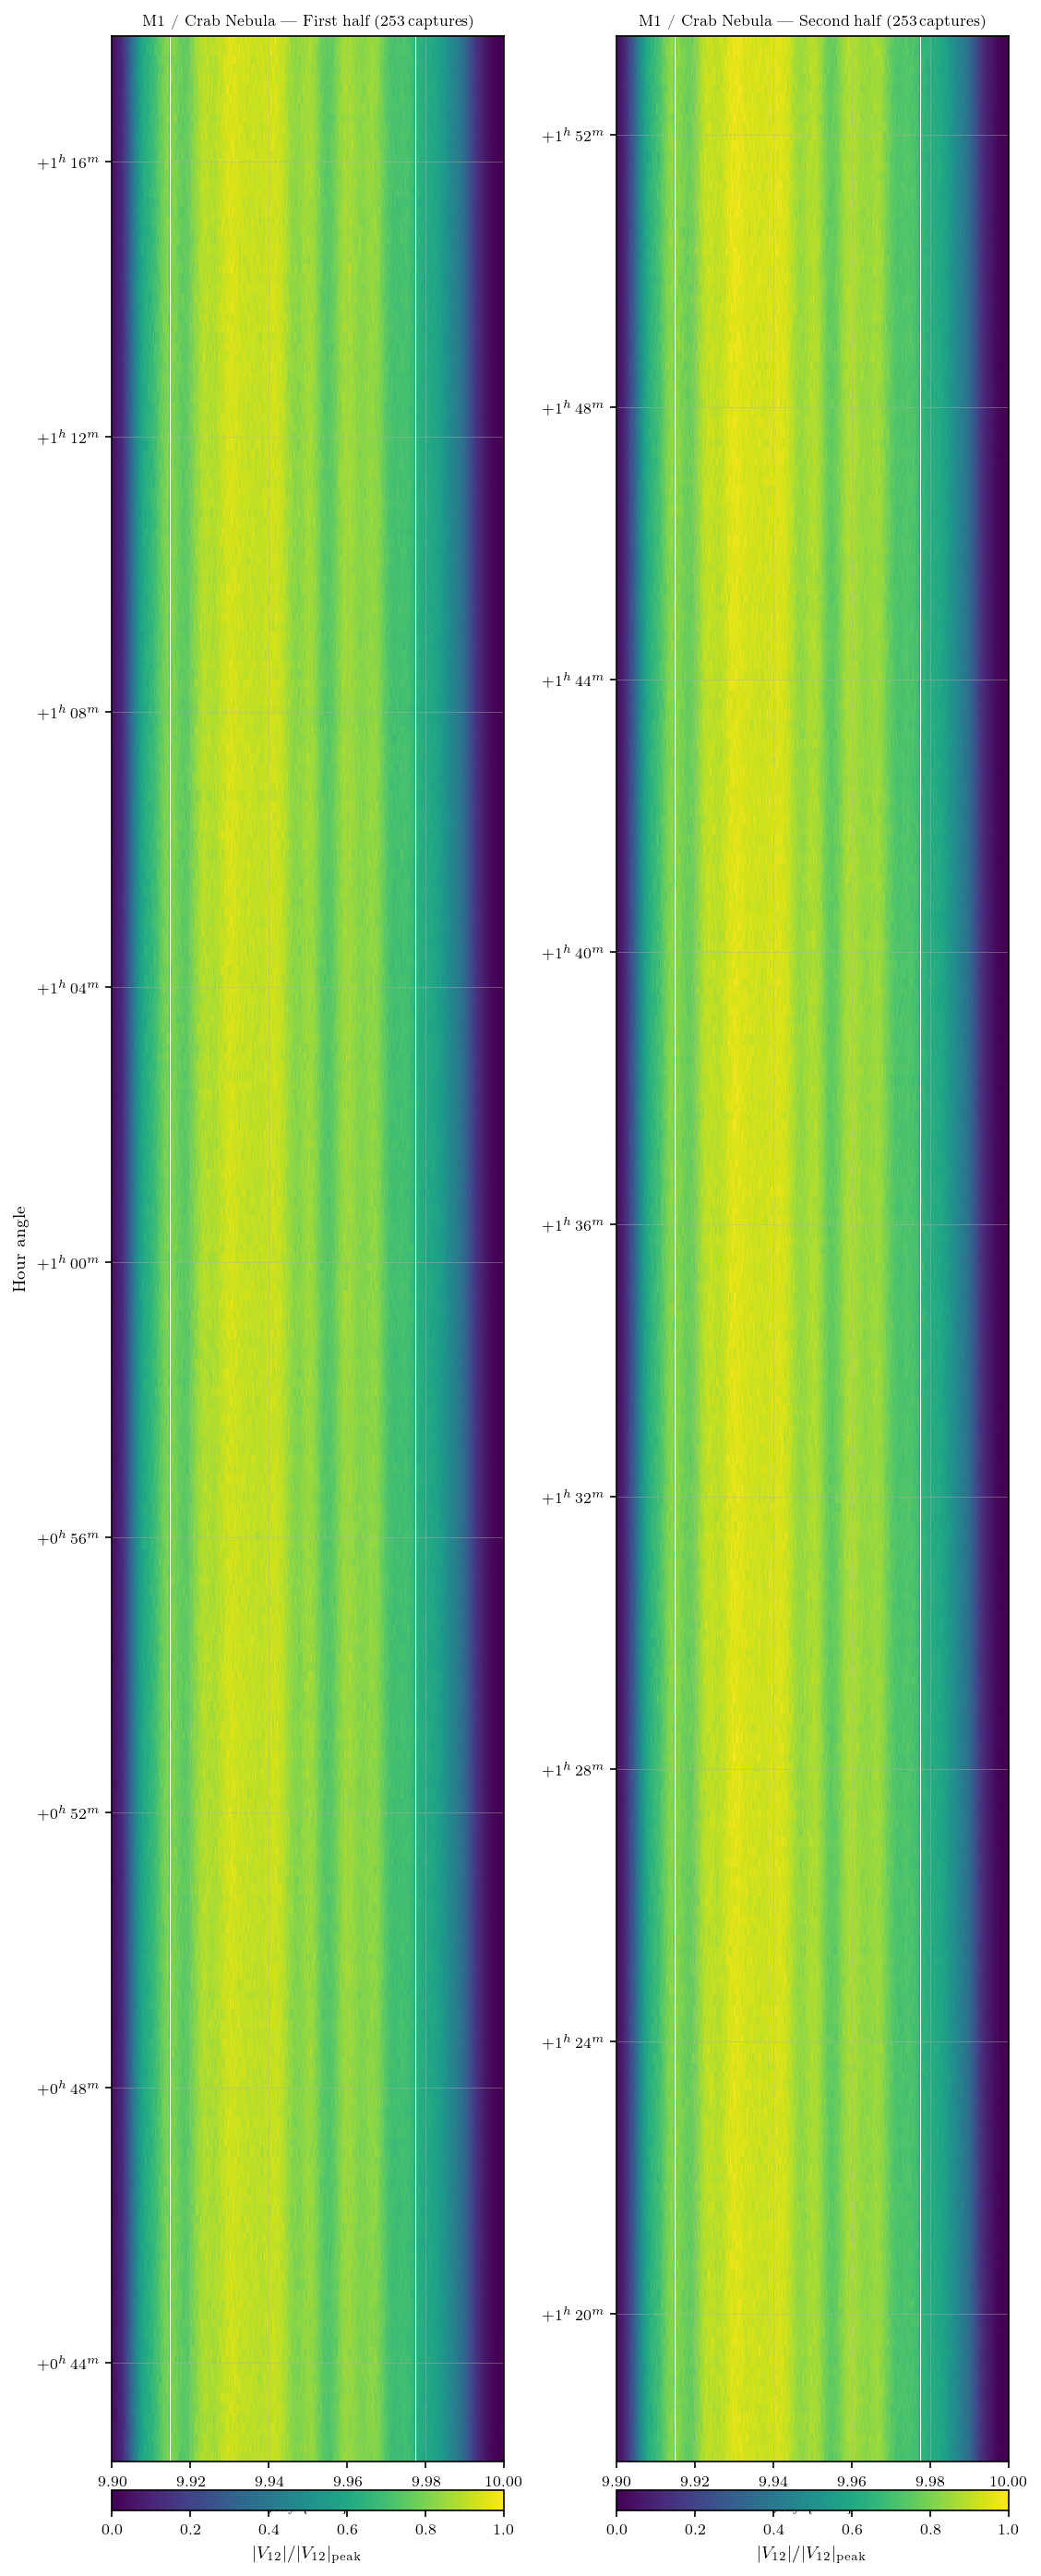

In [4]:
# ---------------------------------------------------------------------------
# Waterfall (spectrogram): amplitude vs frequency × hour angle
# Split chronologically into two halves, shown side by side
# Height scaled: 1 inch per 10 minutes of hour angle (larger half sets height)
# ---------------------------------------------------------------------------

n_half   = len(files_s) // 2
splits   = [
    (files_s[:n_half],  ha_deg[:n_half],  'First half'),
    (files_s[n_half:],  ha_deg[n_half:],  'Second half'),
]

ha_spans_min = [(h.max() - h.min()) / 2.5 * 60 for _, h, _ in splits]
fig_height   = max(ha_spans_min) / 10

fig, axes = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, fig_height),
                          sharey=False, sharex=True)

for ax, (fs_half, ha_half, half_label) in zip(axes, splits):
    amp_matrix = np.array([np.abs(f['corr']) / AMP_PEAK for f in fs_half]).astype(float)
    amp_matrix[:, BAD_CHANNELS] = np.nan

    im = ax.pcolormesh(
        F_SKY_GHZ,
        ha_half,
        amp_matrix,
        vmin=0, vmax=1,
        cmap='viridis',
        shading='auto',
    )
    ax.set_xlim(*PLOT_BAND_GHZ)
    ax.set_xlabel(r'$f_{\rm sky}$ [GHz]')
    ax.set_title(
        rf'M1 / Crab Nebula --- {half_label} ({len(fs_half)}\,captures)',
        fontsize=TICK_SIZE,
    )
    ax.yaxis.set_major_formatter(HA_FMT)
    fig.colorbar(im, ax=ax, location='bottom', shrink=1.0, pad=0.01,
                 label=r'$|V_{12}| / |V_{12}|_{\rm peak}$')

axes[0].set_ylabel('Hour angle')

fig.tight_layout()
plt.show()

Captures        : 506
Wall-clock span : 4238.5 s  (70.6 min)
On-sky total    : 2882.7 s  (48.0 min)
Duty cycle      : 68.0%
n_acc per cap   : min=5  mean=5.7  max=6
Gap (s)         : min=2.64  median=2.68  mean=2.68  max=2.85


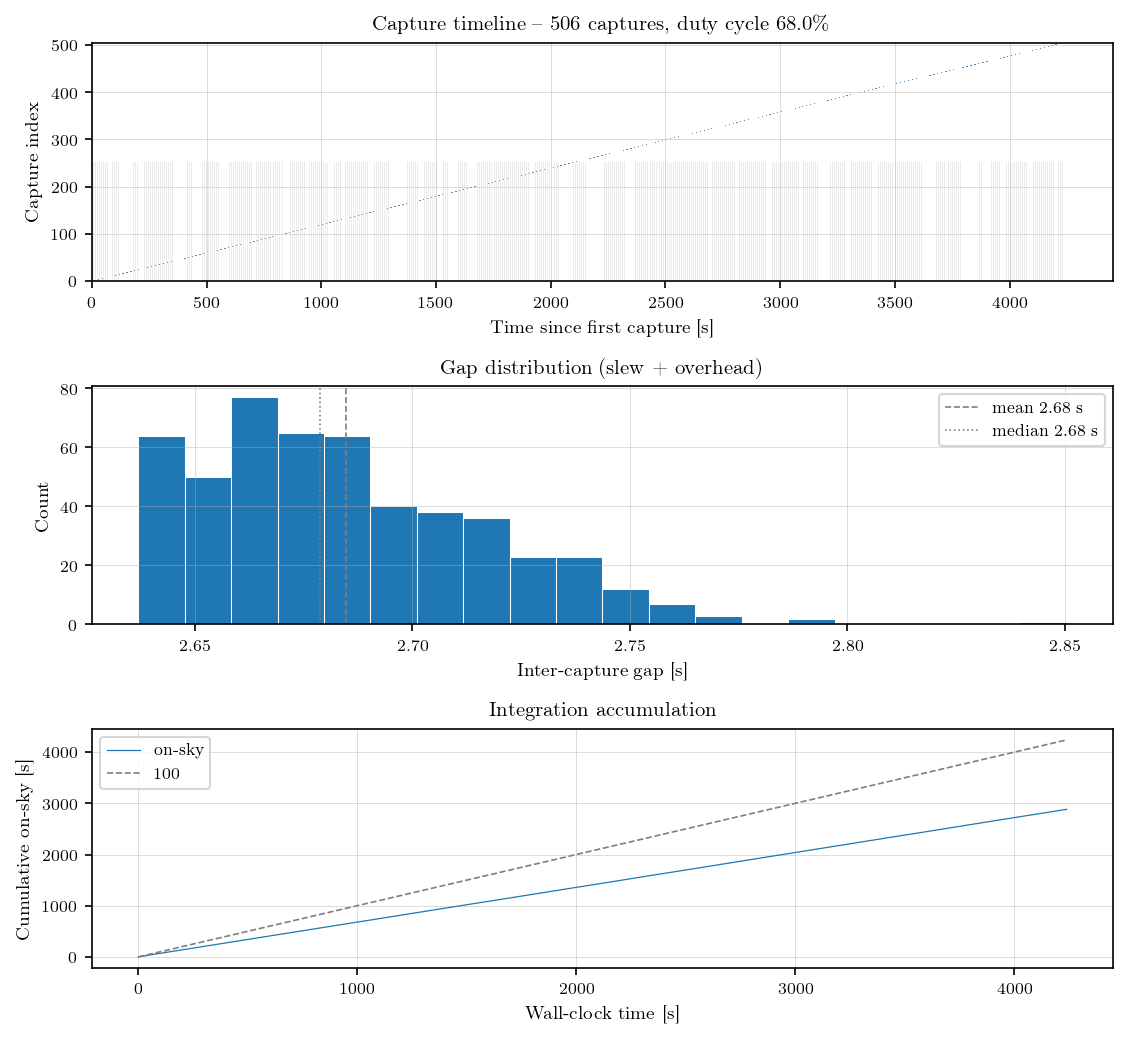

In [5]:
# ---------------------------------------------------------------------------
# Integration time coverage
# ---------------------------------------------------------------------------

t_start = np.array([float(f['unix_time_start']) for f in files_s])
t_end   = np.array([float(f['unix_time_end'])   for f in files_s])
n_acc   = np.array([int(f['n_acc'])             for f in files_s])
durs    = t_end - t_start
gaps    = t_start[1:] - t_end[:-1]
t0      = t_start[0]

total_wall = t_end[-1] - t_start[0]
total_sky  = durs.sum()
duty       = total_sky / total_wall * 100

print(f'Captures        : {len(files_s)}')
print(f'Wall-clock span : {total_wall:.1f} s  ({total_wall/60:.1f} min)')
print(f'On-sky total    : {total_sky:.1f} s  ({total_sky/60:.1f} min)')
print(f'Duty cycle      : {duty:.1f}%')
print(f'n_acc per cap   : min={n_acc.min()}  mean={n_acc.mean():.1f}  max={n_acc.max()}')
print(f'Gap (s)         : min={gaps.min():.2f}  median={np.median(gaps):.2f}  mean={gaps.mean():.2f}  max={gaps.max():.2f}')

# ── 1. Gantt timeline ──────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(TEXTWIDTH_IN, 7))

ax = axes[0]
for i, (ts, te) in enumerate(zip(t_start - t0, t_end - t0)):
    ax.barh(i, te - ts, left=ts, height=0.8, color=PRIMARY_COLOR, alpha=0.8)
# Mark gaps
for ts, te in zip(t_end[:-1] - t0, t_start[1:] - t0):
    ax.barh(0, te - ts, left=ts, height=len(files_s),
            color=NEUTRAL_COLOR, alpha=0.15, zorder=0)
ax.set_xlabel('Time since first capture [s]')
ax.set_ylabel('Capture index')
ax.set_title(rf'Capture timeline -- {len(files_s)} captures, duty cycle {duty:.1f}\%')
ax.set_ylim(-0.5, len(files_s) - 0.5)

# ── 2. Gap histogram ───────────────────────────────────────────────────────
ax = axes[1]
ax.hist(gaps, bins=20, color=PRIMARY_COLOR, edgecolor='white', linewidth=0.5)
ax.axvline(gaps.mean(),   color=NEUTRAL_COLOR, lw=LW_GUIDE, ls='--',
           label=rf'mean {gaps.mean():.2f} s')
ax.axvline(np.median(gaps), color=NEUTRAL_COLOR, lw=LW_GUIDE, ls=':',
           label=rf'median {np.median(gaps):.2f} s')
ax.set_xlabel('Inter-capture gap [s]')
ax.set_ylabel('Count')
ax.set_title('Gap distribution (slew + overhead)')
ax.legend(fontsize=TICK_SIZE)

# ── 3. Cumulative integration vs wall-clock ────────────────────────────────
ax = axes[2]
t_wall = np.concatenate([[0], t_end   - t0])
t_sky  = np.concatenate([[0], np.cumsum(durs)])
ax.plot(t_wall, t_sky,   color=PRIMARY_COLOR, lw=LW_FINE, label='on-sky')
ax.plot([0, t_wall[-1]], [0, t_wall[-1]],
        color=NEUTRAL_COLOR, lw=LW_GUIDE, ls='--', label='100 % duty')
ax.set_xlabel('Wall-clock time [s]')
ax.set_ylabel('Cumulative on-sky [s]')
ax.set_title('Integration accumulation')
ax.legend(fontsize=TICK_SIZE)

fig.tight_layout()
plt.show()